In [257]:
# FinSight AI – Customer Financial Analytics & Risk Prediction

## MCA Final Year Project

### Objective
#Develop a machine learning model that predicts customer financial risk (Low, Medium, High) based on financial attributes and provides insights through data analytics.

### Workflow
#1. Data Loading
#2. Data Cleaning
#3. Exploratory Data Analysis
#4. Target Variable Creation
#5. Data Preprocessing
#6. Model Training
#7. Model Comparison
#8. Best Model Selection
#9. Cross Validation
#10. Prediction

In [258]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

import pickle
import joblib
import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

print("All required libraries imported successfully.")

All required libraries imported successfully.


In [259]:
from google.colab import files
uploaded = files.upload()

Saving synthetic_personal_finance_dataset.csv to synthetic_personal_finance_dataset (5).csv


In [260]:
df = pd.read_csv("synthetic_personal_finance_dataset.csv")
print("Dataset Loaded Successfully.")

Dataset Loaded Successfully.


In [261]:
df.head()
df.tail()
df.shape
df.columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  object 
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  object 
 3   education_level          32424 non-null  object 
 4   employment_status        32424 non-null  object 
 5   job_title                32424 non-null  object 
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  object 
 10  loan_type                12995 non-null  object 
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14  loan_interest_rate_pct

In [262]:
clean_df = df.copy()
print("Working copy of dataset created successfully.")

Working copy of dataset created successfully.


In [263]:
missing_values = clean_df.isnull().sum()
print("Missing Values in Each Column:\n")
print(missing_values)

Missing Values in Each Column:

user_id                        0
age                            0
gender                         0
education_level                0
employment_status              0
job_title                      0
monthly_income_usd             0
monthly_expenses_usd           0
savings_usd                    0
has_loan                       0
loan_type                  19429
loan_amount_usd                0
loan_term_months               0
monthly_emi_usd                0
loan_interest_rate_pct         0
debt_to_income_ratio           0
credit_score                   0
savings_to_income_ratio        0
region                         0
record_date                    0
dtype: int64


In [264]:
duplicate_rows = clean_df.duplicated().sum()
print(f"Duplicate Rows: {duplicate_rows}")

Duplicate Rows: 0


In [265]:
print(clean_df.dtypes)

user_id                     object
age                          int64
gender                      object
education_level             object
employment_status           object
job_title                   object
monthly_income_usd         float64
monthly_expenses_usd       float64
savings_usd                float64
has_loan                    object
loan_type                   object
loan_amount_usd            float64
loan_term_months             int64
monthly_emi_usd            float64
loan_interest_rate_pct     float64
debt_to_income_ratio       float64
credit_score                 int64
savings_to_income_ratio    float64
region                      object
record_date                 object
dtype: object


In [266]:
print("Dataset Shape:", clean_df.shape)

Dataset Shape: (32424, 20)


In [267]:
clean_df.to_csv("cleaned_dataset.csv", index=False)
print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


In [268]:
clean_df.isnull().sum()

,0
user_id,0
age,0
gender,0
education_level,0
employment_status,0
job_title,0
monthly_income_usd,0
monthly_expenses_usd,0
savings_usd,0
has_loan,0


In [269]:
clean_df["loan_type"] = clean_df["loan_type"].fillna("No Loan")
print("Missing values handled successfully.")

Missing values handled successfully.


In [270]:
print(clean_df.isnull().sum())

user_id                    0
age                        0
gender                     0
education_level            0
employment_status          0
job_title                  0
monthly_income_usd         0
monthly_expenses_usd       0
savings_usd                0
has_loan                   0
loan_type                  0
loan_amount_usd            0
loan_term_months           0
monthly_emi_usd            0
loan_interest_rate_pct     0
debt_to_income_ratio       0
credit_score               0
savings_to_income_ratio    0
region                     0
record_date                0
dtype: int64


In [271]:
print("=" * 50)
print("DATA CLEANING SUMMARY")
print("=" * 50)
print(f"Original Shape       : {df.shape}")
print(f"Cleaned Shape        : {clean_df.shape}")
print(f"Duplicate Rows       : {df.duplicated().sum()}")
print(f"Missing Values Left  : {clean_df.isnull().sum().sum()}")
print("\nData cleaning completed successfully.")

DATA CLEANING SUMMARY
Original Shape       : (32424, 20)
Cleaned Shape        : (32424, 20)
Duplicate Rows       : 0
Missing Values Left  : 0

Data cleaning completed successfully.


In [272]:
print("=" * 60)
print("UNKNOWN VALUE CHECK")
print("=" * 60)
for column in clean_df.select_dtypes(include="object").columns:
    unknown_count = (clean_df[column].astype(str).str.lower() == "unknown").sum()
    if unknown_count > 0:
        print(f"{column}: {unknown_count}")

UNKNOWN VALUE CHECK


In [273]:
print("=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

print(clean_df.isnull().sum())

MISSING VALUE CHECK
user_id                    0
age                        0
gender                     0
education_level            0
employment_status          0
job_title                  0
monthly_income_usd         0
monthly_expenses_usd       0
savings_usd                0
has_loan                   0
loan_type                  0
loan_amount_usd            0
loan_term_months           0
monthly_emi_usd            0
loan_interest_rate_pct     0
debt_to_income_ratio       0
credit_score               0
savings_to_income_ratio    0
region                     0
record_date                0
dtype: int64


In [274]:
print("=" * 60)
print("DUPLICATE RECORD CHECK")
print("=" * 60)
duplicate_rows = clean_df.duplicated().sum()
print(f"Duplicate Rows : {duplicate_rows}")

DUPLICATE RECORD CHECK
Duplicate Rows : 0


In [275]:
print("=" * 60)
print("DATASET SHAPE")
print("=" * 60)
print(clean_df.shape)

DATASET SHAPE
(32424, 20)


In [276]:
numerical_columns = clean_df.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = clean_df.select_dtypes(
    include=["object"]
).columns.tolist()

print("=" * 60)
print("NUMERICAL COLUMNS")
print("=" * 60)
print(numerical_columns)

print()

print("=" * 60)
print("CATEGORICAL COLUMNS")
print("=" * 60)
print(categorical_columns)

NUMERICAL COLUMNS
['age', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct', 'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio']

CATEGORICAL COLUMNS
['user_id', 'gender', 'education_level', 'employment_status', 'job_title', 'has_loan', 'loan_type', 'region', 'record_date']


In [277]:
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32424 entries, 0 to 32423
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  32424 non-null  object 
 1   age                      32424 non-null  int64  
 2   gender                   32424 non-null  object 
 3   education_level          32424 non-null  object 
 4   employment_status        32424 non-null  object 
 5   job_title                32424 non-null  object 
 6   monthly_income_usd       32424 non-null  float64
 7   monthly_expenses_usd     32424 non-null  float64
 8   savings_usd              32424 non-null  float64
 9   has_loan                 32424 non-null  object 
 10  loan_type                32424 non-null  object 
 11  loan_amount_usd          32424 non-null  float64
 12  loan_term_months         32424 non-null  int64  
 13  monthly_emi_usd          32424 non-null  float64
 14  loan_interest_rate_pct

In [278]:
clean_df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,32424,32424,U32424,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,32424.0,NaN,NaN,NaN,43.415865,14.978246,18.0,30.0,43.0,56.0,69.0
gender,32424,3,Male,15595,NaN,NaN,NaN,NaN,NaN,NaN,NaN
education_level,32424,5,Bachelor,13038,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_status,32424,4,Employed,19410,NaN,NaN,NaN,NaN,NaN,NaN,NaN
job_title,32424,9,Driver,3698,NaN,NaN,NaN,NaN,NaN,NaN,NaN
monthly_income_usd,32424.0,NaN,NaN,NaN,4027.863185,1916.773353,500.0,2657.795,3997.74,5351.6075,12404.05
monthly_expenses_usd,32424.0,NaN,NaN,NaN,2419.444709,1388.893084,150.01,1397.4975,2219.575,3254.0375,10082.71
savings_usd,32424.0,NaN,NaN,NaN,243752.036091,191577.189517,635.96,86291.55,201700.33,358966.2175,1237774.39
has_loan,32424,2,No,19429,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [279]:
print("=" * 60)
print("DATA CLEANING REPORT")
print("=" * 60)

print(f"Dataset Shape          : {clean_df.shape}")
print(f"Duplicate Records      : {clean_df.duplicated().sum()}")
print(f"Missing Values         : {clean_df.isnull().sum().sum()}")
print(f"Numerical Features     : {len(numerical_columns)}")
print(f"Categorical Features   : {len(categorical_columns)}")

print("\nDataset is ready for Exploratory Data Analysis.")

DATA CLEANING REPORT
Dataset Shape          : (32424, 20)
Duplicate Records      : 0
Missing Values         : 0
Numerical Features     : 11
Categorical Features   : 9

Dataset is ready for Exploratory Data Analysis.


In [280]:
risk_score = (
    (700 - clean_df["credit_score"]) * 0.35 +
    (clean_df["debt_to_income_ratio"] * 100) * 0.35 +
    ((1 - clean_df["savings_to_income_ratio"]) * 100) * 0.30
)

clean_df["Risk_Score"] = risk_score

In [281]:

clean_df["Risk_Category"] = pd.cut(
    clean_df["Risk_Score"],
    bins=[
        clean_df["Risk_Score"].min()-1,
        clean_df["Risk_Score"].quantile(0.30),
        clean_df["Risk_Score"].quantile(0.70),
        clean_df["Risk_Score"].max()+1
    ],
    labels=["Low","Medium","High"]
)

print(clean_df["Risk_Category"].value_counts())

Risk_Category
Medium    12967
Low        9730
High       9727
Name: count, dtype: int64


In [282]:
print(clean_df["Risk_Category"].value_counts())

Risk_Category
Medium    12967
Low        9730
High       9727
Name: count, dtype: int64


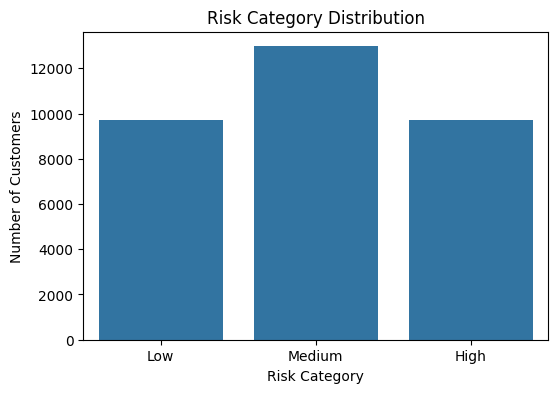

In [283]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=clean_df,
    x="Risk_Category",
    order=["Low", "Medium", "High"]
)

plt.title("Risk Category Distribution")
plt.xlabel("Risk Category")
plt.ylabel("Number of Customers")

plt.show()

In [284]:
clean_df.to_csv("processed_dataset.csv", index=False)

print("Processed dataset saved successfully.")

Processed dataset saved successfully.


In [285]:
X = clean_df.drop(
    columns=[
        "Risk_Category",
        "Risk_Score",
        "user_id",
        "record_date"
    ]
)

y = clean_df["Risk_Category"]
print("Features Shape :", X.shape)
print("Target Shape   :", y.shape)

Features Shape : (32424, 18)
Target Shape   : (32424,)


In [286]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical Columns:")
print(numerical_columns)

print("\nCategorical Columns:")
print(categorical_columns)

Numerical Columns:
['age', 'monthly_income_usd', 'monthly_expenses_usd', 'savings_usd', 'loan_amount_usd', 'loan_term_months', 'monthly_emi_usd', 'loan_interest_rate_pct', 'debt_to_income_ratio', 'credit_score', 'savings_to_income_ratio']

Categorical Columns:
['gender', 'education_level', 'employment_status', 'job_title', 'has_loan', 'loan_type', 'region']


In [287]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print("Training Labels   :", y_train.shape)
print("Testing Labels    :", y_test.shape)

Training Features : (22696, 18)
Testing Features  : (9728, 18)
Training Labels   : (22696,)
Testing Labels    : (9728,)


In [288]:
preprocessor = ColumnTransformer(

    transformers=[

        (
            "num",
            StandardScaler(),
            numerical_columns
        ),

        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_columns
        )

    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [289]:
models = {

    "Decision Tree":
    DecisionTreeClassifier(
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
),

    "Random Forest":
   RandomForestClassifier(
    n_estimators=300,
    max_depth=15,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
),

    "KNN":
  KNeighborsClassifier(
    n_neighbors=7,
    weights="distance"
)

}

In [290]:
trained_models = {}
for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])

    if name == "Naive Bayes":

        X_train_processed = preprocessor.fit_transform(X_train)
        X_test_processed = preprocessor.transform(X_test)

        if hasattr(X_train_processed, "toarray"):
            X_train_processed = X_train_processed.toarray()
            X_test_processed = X_test_processed.toarray()

        model.fit(X_train_processed, y_train)

        trained_models[name] = model

    else:

        pipeline.fit(X_train, y_train)

        trained_models[name] = pipeline

print("All models trained successfully.")

All models trained successfully.


In [291]:
predictions = {}

for name, model in trained_models.items():

    if name == "Naive Bayes":

        pred = model.predict(X_test_processed)

    else:

        pred = model.predict(X_test)

    predictions[name] = pred

print("Predictions completed.")

Predictions completed.


In [292]:
results = []

for name, pred in predictions.items():

    results.append({

        "Model": name,

        "Accuracy": round(accuracy_score(y_test, pred),4),

        "Precision": round(
            precision_score(y_test,pred,average="weighted"),4
        ),

        "Recall": round(
            recall_score(y_test,pred,average="weighted"),4
        ),

        "F1 Score": round(
            f1_score(y_test,pred,average="weighted"),4
        )

    })

results_df = pd.DataFrame(results)

results_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Decision Tree,0.9656,0.9656,0.9656,0.9656
1,Random Forest,0.9439,0.9455,0.9439,0.9441
2,KNN,0.8538,0.8582,0.8538,0.8548


In [293]:
best_model = results_df.iloc[0]
print("=" * 50)
print("BEST MODEL")
print("=" * 50)
print(best_model)

BEST MODEL
Model        Decision Tree
Accuracy            0.9656
Precision           0.9656
Recall              0.9656
F1 Score            0.9656
Name: 0, dtype: object


In [294]:
best_model_name = best_model["Model"]
print("Model :", best_model_name)

print()

print(
    classification_report(
        y_test,
        predictions[best_model_name]
    )
)

Model : Decision Tree

              precision    recall  f1-score   support

        High       0.97      0.97      0.97      2918
         Low       0.98      0.98      0.98      2919
      Medium       0.96      0.96      0.96      3891

    accuracy                           0.97      9728
   macro avg       0.97      0.97      0.97      9728
weighted avg       0.97      0.97      0.97      9728



In [295]:
from sklearn.model_selection import cross_val_score
scores = cross_val_score(
    best_model_pipeline,
    X,
    y,
    cv=5,
    scoring="accuracy"
)

print("=" * 50)
print("CROSS VALIDATION RESULTS")
print("=" * 50)

print("Scores :", scores)
print("Average Accuracy :", round(scores.mean() * 100, 2), "%")

CROSS VALIDATION RESULTS
Scores : [0.96299152 0.96561295 0.96638396 0.96669237 0.96745836]
Average Accuracy : 96.58 %


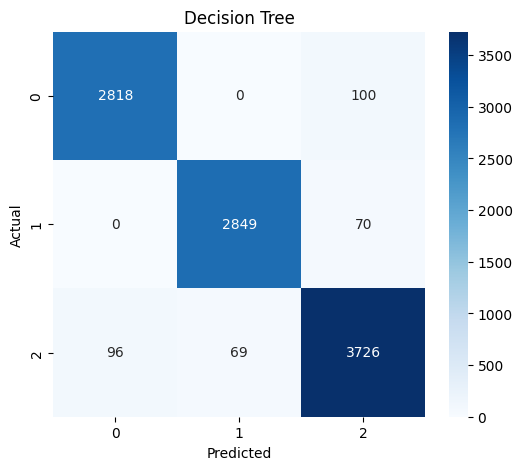

In [296]:
cm = confusion_matrix(
    y_test,
    predictions[best_model_name]
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title(best_model_name)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [297]:
best_model_pipeline = trained_models[best_model_name]

pickle.dump(
    best_model_pipeline,
    open("best_model.pkl", "wb")
)

print("Best model saved successfully.")

Best model saved successfully.


In [298]:
sample_customer = X_test.iloc[[0]]
sample_customer

,age,gender,education_level,employment_status,job_title,monthly_income_usd,monthly_expenses_usd,savings_usd,has_loan,loan_type,loan_amount_usd,loan_term_months,monthly_emi_usd,loan_interest_rate_pct,debt_to_income_ratio,credit_score,savings_to_income_ratio,region
814,33,Female,High School,Employed,Manager,1377.3,840.99,137758.52,No,No Loan,0.0,0,0.0,0.0,0.0,481,8.34,Other


In [299]:
prediction = best_model_pipeline.predict(sample_customer)

print("="*50)
print("FINSIGHT AI PREDICTION")
print("="*50)
print("Predicted Risk :", prediction[0])
print("Actual Risk    :", y_test.iloc[0])

FINSIGHT AI PREDICTION
Predicted Risk : Low
Actual Risk    : Low
